# Spine CT: Vertebra Segmentation + Per-Vertebra Lesion Classification (Swin UNETR)

Runtime: Colab, free **T4 GPU** (`Runtime > Change runtime type > T4 GPU`).


### 1. Install dependencies

`pydicom-seg` is the key addition — it's what correctly decodes multi-segment DICOM-SEG objects instead of treating them as flat binary pixel arrays.

In [1]:
!pip install -q monai SimpleITK pydicom pydicom-seg tcia_utils gradio nibabel pandas openpyxl



In [2]:
!pip install --force-reinstall "numpy>=2.0.0" pandas "monai[pydicom]" SimpleITK pydicom-seg tcia-utils -q


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [8]:
!pip install "pydicom<3.0.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 35.8 MB/s eta 0:00:00
  Attempting uninstall: pydicom
    Found existing installation: pydicom 3.0.2
    Uninstalling pydicom-3.0.2:
      Successfully uninstalled pydicom-3.0.2


In [1]:
import os, re, json, tempfile, shutil, zipfile, random, time
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import SimpleITK as sitk
import pydicom
import pydicom_seg

from monai.apps import download_url
from monai.networks.nets import SwinUNETR
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.transforms import MapTransform, Compose, ScaleIntensityRanged, AsDiscrete
from monai.data import Dataset, DataLoader, MetaTensor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 2. Configuration

Vertebra levels, lesion classes, paths, and shapes used throughout the notebook.

In [2]:
WORK_DIR = "/content"
WEIGHTS_PATH = os.path.join(WORK_DIR, "model_swinvit.pt")
SEG_CHECKPOINT_PATH = os.path.join(WORK_DIR, "best_seg_model.pth")
CLS_CHECKPOINT_PATH = os.path.join(WORK_DIR, "best_cls_model.pth")
DATA_DIR = os.path.join(WORK_DIR, "spine_mets_ct_seg")

# Set this to wherever you've downloaded the Spine-Mets-CT-SEG *clinical* table
# (Excel/CSV with columns including Case, Lytic, Blastic, Mixed). This file ships
# separately from the DICOM collection on TCIA's "Clinical" tab.
CLINICAL_TABLE_PATH = os.path.join(WORK_DIR, "spine_mets_clinical.xlsx")

OUTPUT_SHAPE = (96, 96, 96)          # CT volume grid used for segmentation
CROP_SHAPE = (32, 32, 32)            # fixed-size crop fed to the lesion classifier

# 18 canonical vertebra levels + background = 19-class segmentation problem.
VERTEBRA_LABELS = (
    [f"T{i}" for i in range(1, 13)] +   # T1-T12
    [f"L{i}" for i in range(1, 6)] +    # L1-L5
    ["S1"]                               # sacrum
)
VERTEBRA_TO_IDX = {name: i + 1 for i, name in enumerate(VERTEBRA_LABELS)}  # 1..18, 0 = background
NUM_SEG_CLASSES = len(VERTEBRA_LABELS) + 1

LESION_CLASSES = ["Normal", "Lytic", "Blastic", "Mixed"]
LESION_TO_IDX = {name: i for i, name in enumerate(LESION_CLASSES)}

MIN_VERTEBRA_VOXELS = 30  # below this, treat a vertebra as "not present" in this scan

VERTEBRA_TOKEN_RE = re.compile(r"\b([TLS]\d{1,2})\b")

print(f"Segmentation classes: {NUM_SEG_CLASSES} (background + {len(VERTEBRA_LABELS)} vertebrae)")
print(f"Lesion classes: {LESION_CLASSES}")

Segmentation classes: 19 (background + 18 vertebrae)
Lesion classes: ['Normal', 'Lytic', 'Blastic', 'Mixed']


### 3. Download the pretrained Swin UNETR backbone

Output channels are now `NUM_SEG_CLASSES` (19: background + 18 vertebra levels), not 2.

In [3]:
weights_url = "https://github.com/Project-MONAI/MONAI-extra-test-data/releases/download/0.8.1/model_swinvit.pt"

if not os.path.exists(WEIGHTS_PATH):
    print("Downloading Swin UNETR pretrained backbone weights...")
    download_url(url=weights_url, filepath=WEIGHTS_PATH)
else:
    print("Pretrained weights already present.")

seg_model = SwinUNETR(
    in_channels=1,
    out_channels=NUM_SEG_CLASSES,
    feature_size=48,
    use_checkpoint=True,
)

weights = torch.load(WEIGHTS_PATH, map_location=device, weights_only=True)
seg_model.load_from(weights=weights)
seg_model = seg_model.to(device)

print(f"Swin UNETR backbone ready on {device} with {NUM_SEG_CLASSES} output classes")

model_swinvit.pt: 392MB [00:11, 36.6MB/s]                           

2026-08-02 19:46:56,439 - INFO - Downloaded: /content/model_swinvit.pt
2026-08-02 19:46:56,440 - INFO - Expected md5 is None, skip md5 check for file /content/model_swinvit.pt.


Swin UNETR backbone ready on cuda with 19 output classes


### 4. Download the imaging dataset (Spine-Mets-CT-SEG from TCIA)

Unchanged from the previous version — this only pulls the DICOM CT + DICOM-SEG files, not the clinical table.

In [6]:
COLLECTION = "Spine-Mets-CT-SEG"

os.makedirs(DATA_DIR, exist_ok=True)

if len(os.listdir(DATA_DIR)) == 0:
    try:
        from tcia_utils import nbia
        series_data = nbia.getSeries(collection=COLLECTION)
        df = pd.DataFrame(series_data)
        print(f"Total series found: {len(df)}")
        nbia.downloadSeries(df, input_type="df", path=DATA_DIR)
    except Exception as e:
        print(f"Automatic download failed ({e}). "
              f"Download the '{COLLECTION}' collection manually from TCIA "
              f"and place it under {DATA_DIR}, or upload your own DICOM/DICOM-SEG "
              f"patient folders into that directory.")
else:
    print(f"Data already present in {DATA_DIR}, skipping download.")

Data already present in /content/spine_mets_ct_seg, skipping download.


### 5. Load the clinical annotation table

Parses `Lytic` / `Blastic` / `Mixed` columns into a per-vertebra lesion label for each patient.
Separators inside a cell are inconsistent (commas, spaces, or both — e.g. `"T1, T2 T3, T4"`
actually means T1, T2, T3, T4), so vertebra tokens are pulled out with a regex instead of a naive
`.split(",")`. Any vertebra not mentioned in any of the three columns for a patient is `Normal`.
A patient can have different lesion types at different levels, so this is a per-vertebra label,
not a per-patient one.

In [10]:
import pandas as pd

xls = pd.ExcelFile(CLINICAL_TABLE_PATH)
print("Sheet names:", xls.sheet_names)

for sheet in xls.sheet_names:
    df = pd.read_excel(CLINICAL_TABLE_PATH, sheet_name=sheet)
    print(f"\n--- {sheet} ---")
    print("shape:", df.shape)
    print("columns:", list(df.columns))

Sheet names: ['Data Dictionary', 'Spine-Mets-CT-SEG']

--- Data Dictionary ---
shape: (12, 2)
columns: ['Column Title ', 'Definition']

--- Spine-Mets-CT-SEG ---
shape: (55, 12)
columns: ['Case', 'Age (Y)', 'Sex', 'Height (m)', 'Weight (kg)', 'BMI (kg/m^2)', 'Primary cancer', 'Vertebrae with Lesions', 'Blastic', 'Lytic', 'Mixed', 'Comments/Fractures']


In [11]:
CLINICAL_TABLE_URL = "https://www.cancerimagingarchive.net/wp-content/uploads/Spine-Mets-CT-SEG_Clinical.xlsx"
CLINICAL_SHEET_NAME = "Spine-Mets-CT-SEG"

patient_lesion_labels = {}

if not os.path.exists(CLINICAL_TABLE_PATH):
    try:
        print(f"Downloading clinical table from {CLINICAL_TABLE_URL} ...")
        download_url(url=CLINICAL_TABLE_URL, filepath=CLINICAL_TABLE_PATH)
    except Exception as e:
        print(f"Automatic download failed ({e}). Download it manually from the URL above "
              f"and place it at {CLINICAL_TABLE_PATH}.")

if os.path.exists(CLINICAL_TABLE_PATH):
    if CLINICAL_TABLE_PATH.lower().endswith((".xlsx", ".xls")):
        data_df = pd.read_excel(CLINICAL_TABLE_PATH, sheet_name=CLINICAL_SHEET_NAME)
    else:
        data_df = pd.read_csv(CLINICAL_TABLE_PATH)

    for _, row in data_df.iterrows():
        patient_id = str(row["Case"]).strip()
        patient_lesion_labels[patient_id] = build_lesion_labels_for_patient(row)

    print(f"Loaded clinical labels for {len(patient_lesion_labels)} patients.")
    for pid in list(patient_lesion_labels.keys())[:5]:
        print(f"  {pid}: {patient_lesion_labels[pid]}")
else:
    print(f"CLINICAL_TABLE_PATH not found at {CLINICAL_TABLE_PATH}. "
          f"Download the Spine-Mets-CT-SEG clinical table from TCIA's 'Clinical' tab, "
          f"set CLINICAL_TABLE_PATH above, and re-run this cell. "
          f"Without it, every vertebra will default to 'Normal' and the classifier "
          f"will have nothing meaningful to learn.")

Loaded clinical labels for 55 patients.
  10250: {'T2': 'Mixed'}
  10352: {}
  10355: {'T4': 'Mixed', 'T5': 'Mixed', 'T11': 'Mixed', 'T2': 'Mixed', 'L3': 'Mixed', 'L5': 'Mixed', 'T7': 'Mixed', 'T1': 'Mixed', 'T8': 'Mixed', 'T12': 'Mixed', 'T6': 'Mixed', 'L1': 'Mixed', 'L4': 'Mixed', 'T3': 'Mixed', 'T9': 'Mixed', 'L2': 'Mixed', 'T10': 'Mixed'}
  10456: {'L1': 'Lytic', 'T11': 'Lytic'}
  10458: {'L1': 'Blastic'}


### 6. Pair each CT volume with its segmentation mask

Unchanged from the previous version: a folder with multiple `.dcm` files is a CT series, a folder with a single `.dcm` file is a DICOM-SEG mask, matched by `FrameOfReferenceUID`.

In [13]:
def find_dicom_dir(root_dir):
    for r, _, files in os.walk(root_dir):
        if any(f.lower().endswith(".dcm") for f in files):
            return r
    return None


def build_data_pairs(base_dir):
    ct_groups = {}
    mask_groups = {}

    for folder in sorted(os.listdir(base_dir)):
        folder_path = os.path.join(base_dir, folder)
        if not os.path.isdir(folder_path):
            continue

        dcm_files = [f for f in os.listdir(folder_path) if f.lower().endswith(".dcm")]
        if not dcm_files:
            continue

        sample_dcm = os.path.join(folder_path, dcm_files[0])
        try:
            ds = pydicom.dcmread(sample_dcm, stop_before_pixels=True)
            for_uid = getattr(ds, "FrameOfReferenceUID", "Unknown")
        except Exception:
            continue

        if len(dcm_files) > 1:
            ct_groups[for_uid] = folder_path
        else:
            mask_groups[for_uid] = sample_dcm

    dataset_dicts = []
    for for_uid, ct_path in ct_groups.items():
        if for_uid in mask_groups:
            dataset_dicts.append({"image": ct_path, "label": mask_groups[for_uid]})

    print(f"Paired {len(dataset_dicts)} CT/mask volumes.")
    return dataset_dicts


raw_data_dicts = build_data_pairs(DATA_DIR)

if len(raw_data_dicts) == 0:
    print("No paired CT/segmentation volumes were found. "
          "Add data under the data directory before running the training cells.")

Paired 55 CT/mask volumes.


### 7. Attach `PatientID` and clinical lesion labels to each pair

`PatientID` in the DICOM header is a bare number (e.g. `"10543"`), matching the clinical table's
`Case` column once both are cast to string — confirmed by inspecting a sample file from each
series. Patients missing from the clinical table keep an empty label dict (every vertebra defaults
to Normal for classification purposes) rather than being silently dropped, but are flagged so a
join-key mismatch is visible immediately instead of quietly producing an all-Normal dataset.

In [15]:
def get_patient_id(image_path):
    if os.path.isdir(image_path):
        dcm_filename = [f for f in os.listdir(image_path) if f.lower().endswith(".dcm")][0]
        full_path = os.path.join(image_path, dcm_filename)
    else:
        full_path = image_path
    ds = pydicom.dcmread(full_path, stop_before_pixels=True)
    return str(getattr(ds, "PatientID", "Unknown")).strip()


data_dicts = []
unmatched_patients = []

for pair in raw_data_dicts:
    pid = get_patient_id(pair["image"])
    lesion_labels = patient_lesion_labels.get(pid)
    if lesion_labels is None:
        unmatched_patients.append(pid)
        lesion_labels = {}

    data_dicts.append({
        "image": pair["image"],
        "label": pair["label"],
        "patient_id": pid,
        "lesion_labels": lesion_labels,
    })

print(f"Total volumes: {len(data_dicts)}")
print(f"Matched to clinical table: {len(data_dicts) - len(unmatched_patients)}")
if unmatched_patients:
    print(f"WARNING: {len(unmatched_patients)} patients had no clinical-table match "
          f"(defaulting to all-Normal): {unmatched_patients[:10]}"
          f"{' ...' if len(unmatched_patients) > 10 else ''}")

Total volumes: 55
Matched to clinical table: 55


In [16]:
for pair in raw_data_dicts[:5]:
    pid = get_patient_id(pair["image"])
    print(f"DICOM PatientID: '{pid}'  ->  in clinical table: {pid in patient_lesion_labels}")

DICOM PatientID: '10543'  ->  in clinical table: True
DICOM PatientID: '14487'  ->  in clinical table: True
DICOM PatientID: '14636'  ->  in clinical table: True
DICOM PatientID: '14293'  ->  in clinical table: True
DICOM PatientID: '12196'  ->  in clinical table: True


### 8. DICOM-SEG decoding

`pydicom_seg.MultiClassReader` parses `SegmentSequence` + `PerFrameFunctionalGroupsSequence`
properly, returning one combined label volume where each voxel's value is a **segment number**
(not a flat 0/255 mask), plus per-segment metadata. Segment `SegmentLabel`/`SegmentDescription`
text is parsed with the same vertebra-token regex used on the clinical table to map each segment
number to one of the 18 canonical vertebra indices.

In [18]:
def inspect_seg_metadata(seg_file_path):
    '''Diagnostic: print what's actually inside a DICOM-SEG file's segment metadata.'''
    ds = pydicom.dcmread(seg_file_path)

    print(f"File: {seg_file_path}")
    print(f"Modality: {getattr(ds, 'Modality', 'Unknown')}")
    print(f"Number of frames: {getattr(ds, 'NumberOfFrames', 'N/A')}")

    if hasattr(ds, "SegmentSequence"):
        print(f"Number of segments: {len(ds.SegmentSequence)}")
        for seg in ds.SegmentSequence:
            number = getattr(seg, "SegmentNumber", "?")
            label = getattr(seg, "SegmentLabel", "?")
            description = getattr(seg, "SegmentDescription", "")
            print(f"  Segment {number}: label='{label}'  description='{description}'")
    else:
        print("No SegmentSequence found - this file may not be a standard DICOM-SEG object.")
    print("-" * 80)


def decode_dicom_seg(seg_path):
    '''
    Returns:
      seg_sitk_image: SimpleITK image whose voxel values are segment numbers (0 = background)
      segment_to_vertebra_idx: dict mapping segment number -> vertebra index (1..18),
                                 segments that don't match a known vertebra token are dropped.
    '''
    ds = pydicom.dcmread(seg_path)
    reader = pydicom_seg.MultiClassReader()
    result = reader.read(ds)
    seg_sitk_image = result.image  # geometry matches the referenced CT series

    segment_to_vertebra_idx = {}
    unmapped_segments = []
    for seg in ds.SegmentSequence:
        number = int(getattr(seg, "SegmentNumber"))
        label_text = f"{getattr(seg, 'SegmentLabel', '')} {getattr(seg, 'SegmentDescription', '')}"
        tokens = VERTEBRA_TOKEN_RE.findall(label_text.upper())
        if tokens and tokens[0] in VERTEBRA_TO_IDX:
            segment_to_vertebra_idx[number] = VERTEBRA_TO_IDX[tokens[0]]
        else:
            unmapped_segments.append((number, label_text.strip()))

    if unmapped_segments:
        print(f"  [decode_dicom_seg] {os.path.basename(seg_path)}: "
              f"{len(unmapped_segments)} segment(s) didn't match a known vertebra token "
              f"and will be treated as background: {unmapped_segments}")

    return seg_sitk_image, segment_to_vertebra_idx

### 8b. Diagnostic: inspect real segment metadata before building the training pipeline

In [19]:
for sample_dict in data_dicts[:3]:
    inspect_seg_metadata(sample_dict["label"])

File: /content/spine_mets_ct_seg/1.3.6.1.4.1.14519.5.2.1.329966518031016842208719673039837235728/1-1.dcm
Modality: SEG
Number of frames: 1652
Number of segments: 15
  Segment 1: label='T1 vertebra'  description=''
  Segment 2: label='T2 vertebra'  description=''
  Segment 3: label='T3 vertebra'  description=''
  Segment 4: label='T4 vertebra'  description=''
  Segment 5: label='T5 vertebra'  description=''
  Segment 6: label='T6 vertebra'  description=''
  Segment 7: label='T7 vertebra'  description=''
  Segment 8: label='T8 vertebra'  description=''
  Segment 9: label='T9 vertebra'  description=''
  Segment 10: label='T10 vertebra'  description=''
  Segment 11: label='T11 vertebra'  description=''
  Segment 12: label='T12 vertebra'  description=''
  Segment 13: label='L1 vertebra'  description=''
  Segment 14: label='L2 vertebra'  description=''
  Segment 15: label='L3 vertebra'  description=''
--------------------------------------------------------------------------------
File: /con

### 9. Train / validation split

In [23]:
random.seed(42)
shuffled = data_dicts.copy()
random.shuffle(shuffled)

val_fraction = 0.1
n_val = max(1, int(len(shuffled) * val_fraction)) if len(shuffled) > 1 else 0

val_files = shuffled[:n_val]
train_files = shuffled[n_val:]

print(f"Train volumes: {len(train_files)} | Validation volumes: {len(val_files)}")

Train volumes: 50 | Validation volumes: 5


### 10. Loading & preprocessing pipeline

Same physical-alignment fix as before (the label is resampled onto the CT's own resampled grid,
not its own independent grid), now applied to the decoded per-vertebra label map instead of a
binary mask. Also builds two auxiliary per-volume targets:
- `lesion_targets`: a fixed-length vector (one entry per vertebra level) with the clinical lesion
  class index for that level.
- `vertebra_present`: a boolean vector marking which vertebra levels actually appear in *this*
  particular scan (many scans only cover part of the spine), so absent levels aren't scored.

In [43]:
class LoadMultiTaskDICOMd(MapTransform):
    def __init__(self, keys, output_shape=OUTPUT_SHAPE):
        super().__init__(keys)
        self.output_shape = output_shape

    def _read_ct(self, path):
        reader = sitk.ImageSeriesReader()
        dicom_names = reader.GetGDCMSeriesFileNames(path)
        reader.SetFileNames(dicom_names)
        image = reader.Execute()

        if image.GetDimension() == 4:
            size = image.GetSize()
            image = sitk.Extract(image, (size[0], size[1], size[2], 0), (0, 0, 0, 0))
        return image

    def _resample_to_shape(self, image, is_label):
        original_spacing = image.GetSpacing()
        original_size = image.GetSize()

        new_spacing = [
            (original_size[i] * original_spacing[i]) / self.output_shape[i]
            for i in range(3)
        ]

        resample = sitk.ResampleImageFilter()
        resample.SetInterpolator(sitk.sitkNearestNeighbor if is_label else sitk.sitkLinear)
        resample.SetOutputSpacing(new_spacing)
        resample.SetSize(self.output_shape)
        resample.SetOutputDirection(image.GetDirection())
        resample.SetOutputOrigin(image.GetOrigin())

        return resample.Execute(image)

    def _resample_to_reference(self, image, reference):
        return sitk.Resample(
            image, reference, sitk.Transform(), sitk.sitkNearestNeighbor, 0, image.GetPixelID(),
        )

    def __call__(self, data):
        d = dict(data)

        ct_image = self._read_ct(d["image"])
        ct_resampled = self._resample_to_shape(ct_image, is_label=False)

        seg_image, segment_to_vertebra_idx = decode_dicom_seg(d["label"])
        seg_resampled = self._resample_to_reference(seg_image, ct_resampled)

        ct_array = sitk.GetArrayFromImage(ct_resampled).astype(np.float32)
        raw_seg_array = sitk.GetArrayFromImage(seg_resampled).astype(np.int32)

        # remap segment numbers -> vertebra indices (0 = background / unmapped)
        vertebra_array = np.zeros_like(raw_seg_array, dtype=np.int64)
        for seg_number, vertebra_idx in segment_to_vertebra_idx.items():
            vertebra_array[raw_seg_array == seg_number] = vertebra_idx

        lesion_labels = d.get("lesion_labels", {})
        lesion_targets = np.zeros(len(VERTEBRA_LABELS), dtype=np.int64)      # default: Normal
        vertebra_present = np.zeros(len(VERTEBRA_LABELS), dtype=np.float32)

        for i, name in enumerate(VERTEBRA_LABELS):
            voxel_count = int(np.sum(vertebra_array == (i + 1)))
            if voxel_count >= MIN_VERTEBRA_VOXELS:
                vertebra_present[i] = 1.0
                lesion_class = lesion_labels.get(name, "Normal")
                lesion_targets[i] = LESION_TO_IDX.get(lesion_class, LESION_TO_IDX["Normal"])

        d["image"] = MetaTensor(np.expand_dims(ct_array, axis=0))
        d["label"] = MetaTensor(np.expand_dims(vertebra_array.astype(np.float32), axis=0))
        d["lesion_targets"] = torch.as_tensor(lesion_targets)
        d["vertebra_present"] = torch.as_tensor(vertebra_present)
        # Drop raw, variable-shape fields the default collate can't batch across samples
        # (different patients have different sets of affected vertebrae, e.g. one sample
        # might have key 'L3' and another might not, which crashes dict collation).
        d.pop("lesion_labels", None)
        d.pop("patient_id", None)
        return d


train_transforms = Compose([
    LoadMultiTaskDICOMd(keys=["image", "label"]),
    ScaleIntensityRanged(keys=["image"], a_min=-200, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
])

# batch_size=1: each volume has a variable number of present vertebrae, which the
# per-vertebra classifier step below loops over per-sample rather than collating.
train_ds = Dataset(data=train_files, transform=train_transforms)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0)

val_ds = Dataset(data=val_files, transform=train_transforms)
val_loader = DataLoader(val_ds, batch_size=2, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)} | Validation batches: {len(val_loader)}")

Train batches: 13 | Validation batches: 3


### 10b. Diagnostic: verify vertebra alignment and per-vertebra targets before training

In [44]:
sample = train_ds[0]
print("Image shape:", sample["image"].shape)
print("Label shape:", sample["label"].shape)
print("Unique label values (vertebra indices present):", np.unique(sample["label"]))

present_idx = np.where(sample["vertebra_present"].numpy() > 0)[0]
print()
print("Vertebrae present in this scan and their lesion target:")
for i in present_idx:
    name = VERTEBRA_LABELS[i]
    lesion = LESION_CLASSES[int(sample["lesion_targets"][i])]
    voxels = int((sample["label"] == (i + 1)).sum())
    print(f"  {name}: {lesion}  ({voxels} voxels)")

Image shape: torch.Size([1, 96, 96, 96])
Label shape: torch.Size([1, 96, 96, 96])
Unique label values (vertebra indices present): [0.]

Vertebrae present in this scan and their lesion target:


### 11. Freeze the pretrained encoder

Same as before: keeps the heavy Swin transformer backbone frozen and only fine-tunes the decoder / segmentation head.

In [45]:
for name, param in seg_model.named_parameters():
    if "swinViT" in name or "encoder" in name:
        param.requires_grad = False

trainable = sum(p.numel() for p in seg_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in seg_model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Trainable params: 19,598,755 / 62,187,541


### 12. Lesion classifier and vertebra-crop utility

A small 3D CNN that takes a fixed-size CT sub-volume cropped around one vertebra and predicts its
lesion class. `crop_vertebra` extracts that sub-volume using the (ground-truth, during training)
vertebra label map to find the bounding box, with a small margin, then resizes it to `CROP_SHAPE`.

In [46]:
class VertebraLesionClassifier3D(nn.Module):
    def __init__(self, num_classes=len(LESION_CLASSES)):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(1, 16, kernel_size=3, padding=1), nn.BatchNorm3d(16), nn.ReLU(inplace=True),
            nn.MaxPool3d(2),                                                   # 32 -> 16
            nn.Conv3d(16, 32, kernel_size=3, padding=1), nn.BatchNorm3d(32), nn.ReLU(inplace=True),
            nn.MaxPool3d(2),                                                   # 16 -> 8
            nn.Conv3d(32, 64, kernel_size=3, padding=1), nn.BatchNorm3d(64), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool3d(1),
        )
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        feats = self.features(x).flatten(1)
        return self.classifier(feats)


def crop_vertebra(ct_volume, label_volume, vertebra_idx, crop_shape=CROP_SHAPE, margin=4):
    '''
    ct_volume, label_volume: (D, H, W) tensors for a single sample (batch/channel dims removed).
    Returns a (1, 1, *crop_shape) tensor, or None if the vertebra isn't present.
    '''
    mask = (label_volume == vertebra_idx)
    if mask.sum() == 0:
        return None

    coords = torch.nonzero(mask)
    mins = coords.min(dim=0).values
    maxs = coords.max(dim=0).values

    d0, h0, w0 = [max(0, int(m) - margin) for m in mins]
    d1, h1, w1 = [min(s, int(m) + margin + 1) for m, s in zip(maxs, ct_volume.shape)]

    crop = ct_volume[d0:d1, h0:h1, w0:w1]
    crop = crop.unsqueeze(0).unsqueeze(0)  # (1, 1, d, h, w)
    crop = F.interpolate(crop, size=crop_shape, mode="trilinear", align_corners=False)
    return crop


lesion_classifier = VertebraLesionClassifier3D().to(device)
print("Lesion classifier ready.")

Lesion classifier ready.


### 13. Loss functions, metrics, and optimizer

One combined optimizer over the unfrozen segmentation decoder and the classifier.

In [47]:
seg_loss_function = DiceCELoss(to_onehot_y=True, softmax=True)
dice_metric = DiceMetric(include_background=False, reduction="mean")
cls_loss_function = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    list(filter(lambda p: p.requires_grad, seg_model.parameters())) + list(lesion_classifier.parameters()),
    lr=2e-5,
    weight_decay=1e-2,
)

CLS_LOSS_WEIGHT = 0.5  # relative weight of the classification loss vs. segmentation loss

print("Losses, metric, and optimizer ready.")

Losses, metric, and optimizer ready.


### 14. Training loop

Per volume: run segmentation, compute Dice+CE loss; then, for every vertebra actually present in
that scan, crop it out of the CT (using the **ground-truth** vertebra map during training, so the
classifier learns from correctly localized crops rather than the segmentation model's early,
noisy predictions) and classify it, averaging cross-entropy across present vertebrae. Total loss
is `seg_loss + CLS_LOSS_WEIGHT * cls_loss`. Validation reports both segmentation Dice and
classification accuracy, and the best checkpoint (by their average) is saved for both models.

If you're re-running this after changing `NUM_SEG_CLASSES`, `VERTEBRA_LABELS`, or the label
pipeline, delete any old checkpoints first and re-run from Section 3 onward so `seg_model` is a
fresh, untrained instance.

In [48]:
from tqdm.auto import tqdm

for path in (SEG_CHECKPOINT_PATH, CLS_CHECKPOINT_PATH):
    if os.path.exists(path):
        os.remove(path)
        print(f"Removed old checkpoint: {path}")

num_epochs = 10
best_combined_score = -1.0
history = {"train_seg_loss": [], "train_cls_loss": [], "val_dice": [], "val_cls_acc": [], "epoch_time": []}

post_pred = AsDiscrete(argmax=True, to_onehot=NUM_SEG_CLASSES)
post_label = AsDiscrete(to_onehot=NUM_SEG_CLASSES)

training_start = time.time()

for epoch in range(num_epochs):
    seg_model.train()
    lesion_classifier.train()
    epoch_seg_loss = 0.0
    epoch_cls_loss = 0.0
    n_cls_steps = 0
    step_times = []
    epoch_start = time.time()

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)
    for batch_data in progress_bar:
        step_start = time.time()

        inputs = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)
        lesion_targets = batch_data["lesion_targets"][0]      # batch_size=1
        vertebra_present = batch_data["vertebra_present"][0]

        optimizer.zero_grad()

        seg_outputs = seg_model(inputs)
        loss_seg = seg_loss_function(seg_outputs, labels)

        # classification step: crop each present vertebra from the ground-truth label map
        ct_vol = inputs[0, 0]      # (D, H, W)
        label_vol = labels[0, 0]   # (D, H, W)
        present_idx = torch.nonzero(vertebra_present).squeeze(-1)

        loss_cls = torch.tensor(0.0, device=device)
        if len(present_idx) > 0:
            crops, targets = [], []
            for i in present_idx.tolist():
                crop = crop_vertebra(ct_vol, label_vol, vertebra_idx=i + 1)
                if crop is not None:
                    crops.append(crop)
                    targets.append(lesion_targets[i])
            if crops:
                crops_batch = torch.cat(crops, dim=0).to(device)
                targets_batch = torch.stack(targets).to(device)
                logits = lesion_classifier(crops_batch)
                loss_cls = cls_loss_function(logits, targets_batch)
                epoch_cls_loss += loss_cls.item()
                n_cls_steps += 1

        total_loss = loss_seg + CLS_LOSS_WEIGHT * loss_cls
        total_loss.backward()
        optimizer.step()

        step_times.append(time.time() - step_start)
        epoch_seg_loss += loss_seg.item()

        avg_step_time = sum(step_times) / len(step_times)
        eta_epoch = avg_step_time * (len(train_loader) - len(step_times))
        progress_bar.set_postfix({
            "seg_loss": f"{loss_seg.item():.4f}",
            "cls_loss": f"{loss_cls.item():.4f}",
            "s/step": f"{avg_step_time:.2f}",
            "ETA epoch": f"{eta_epoch:.0f}s",
        })

    epoch_seg_loss /= max(len(step_times), 1)
    epoch_cls_loss /= max(n_cls_steps, 1)
    epoch_duration = time.time() - epoch_start

    # ---- validation ----
    seg_model.eval()
    lesion_classifier.eval()
    dice_metric.reset()
    cls_correct, cls_total = 0, 0

    with torch.no_grad():
        for val_data in val_loader:
            val_inputs = val_data["image"].to(device)
            val_labels = val_data["label"].to(device)
            val_lesion_targets = val_data["lesion_targets"][0]
            val_present = val_data["vertebra_present"][0]

            val_outputs = seg_model(val_inputs)
            val_outputs_list = [post_pred(o) for o in val_outputs]
            val_labels_list = [post_label(l) for l in val_labels]
            dice_metric(y_pred=val_outputs_list, y=val_labels_list)

            ct_vol = val_inputs[0, 0]
            label_vol = val_labels[0, 0]
            for i in torch.nonzero(val_present).squeeze(-1).tolist():
                crop = crop_vertebra(ct_vol, label_vol, vertebra_idx=i + 1)
                if crop is None:
                    continue
                logits = lesion_classifier(crop.to(device))
                pred_class = torch.argmax(logits, dim=1).item()
                cls_correct += int(pred_class == val_lesion_targets[i].item())
                cls_total += 1

    val_dice = dice_metric.aggregate().item() if len(val_loader) > 0 else 0.0
    val_cls_acc = cls_correct / cls_total if cls_total > 0 else 0.0
    combined_score = (val_dice + val_cls_acc) / 2

    elapsed_total = time.time() - training_start
    eta_total = (elapsed_total / (epoch + 1)) * (num_epochs - (epoch + 1))

    print(f"Epoch {epoch+1:02d}/{num_epochs} | Seg loss: {epoch_seg_loss:.4f} | "
          f"Cls loss: {epoch_cls_loss:.4f} | Val Dice: {val_dice:.4f} | "
          f"Val Cls Acc: {val_cls_acc:.4f} | Epoch time: {epoch_duration:.1f}s | "
          f"Est. remaining: {eta_total/60:.1f} min")

    history["train_seg_loss"].append(epoch_seg_loss)
    history["train_cls_loss"].append(epoch_cls_loss)
    history["val_dice"].append(val_dice)
    history["val_cls_acc"].append(val_cls_acc)
    history["epoch_time"].append(epoch_duration)

    if combined_score > best_combined_score:
        best_combined_score = combined_score
        torch.save(seg_model.state_dict(), SEG_CHECKPOINT_PATH)
        torch.save(lesion_classifier.state_dict(), CLS_CHECKPOINT_PATH)
        print(f"  Saved new best checkpoints (combined score: {best_combined_score:.4f})")

total_duration = time.time() - training_start
print(f"Training complete in {total_duration/60:.1f} min. Best combined score: {best_combined_score:.4f}")

Epoch 1/10:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 01/10 | Seg loss: 3.7567 | Cls loss: 1.5192 | Val Dice: 0.0006 | Val Cls Acc: 0.0000 | Epoch time: 293.9s | Est. remaining: 48.6 min
  Saved new best checkpoints (combined score: 0.0003)


Epoch 2/10:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 02/10 | Seg loss: 3.5687 | Cls loss: 1.4958 | Val Dice: 0.0005 | Val Cls Acc: 0.0000 | Epoch time: 304.9s | Est. remaining: 44.2 min


Epoch 3/10:   0%|          | 0/13 [00:00<?, ?it/s]

...

Epoch 08/10 | Seg loss: 3.1591 | Cls loss: 1.4318 | Val Dice: 0.0020 | Val Cls Acc: 0.0000 | Epoch time: 324.1s | Est. remaining: 11.5 min
  Saved new best checkpoints (combined score: 0.0010)


Epoch 9/10:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 09/10 | Seg loss: 3.1226 | Cls loss: 1.4286 | Val Dice: 0.0021 | Val Cls Acc: 0.0238 | Epoch time: 323.8s | Est. remaining: 5.8 min
  Saved new best checkpoints (combined score: 0.0130)


Epoch 10/10:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 10/10 | Seg loss: 3.0858 | Cls loss: 1.3911 | Val Dice: 0.0022 | Val Cls Acc: 0.0238 | Epoch time: 336.7s | Est. remaining: 0.0 min
  Saved new best checkpoints (combined score: 0.0130)
Training complete in 58.6 min. Best combined score: 0.0130


### 15. Training curves

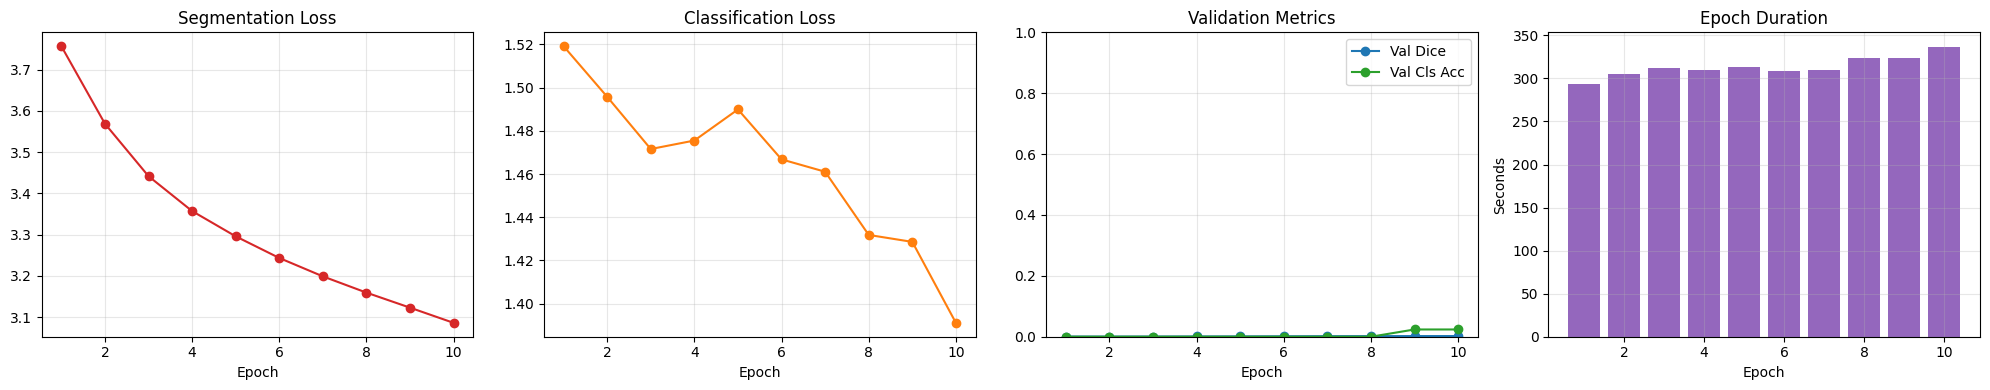

In [49]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_seg_loss"]) + 1)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].plot(epochs_range, history["train_seg_loss"], marker="o", color="tab:red")
axes[0].set_title("Segmentation Loss")
axes[0].set_xlabel("Epoch"); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_cls_loss"], marker="o", color="tab:orange")
axes[1].set_title("Classification Loss")
axes[1].set_xlabel("Epoch"); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_range, history["val_dice"], marker="o", color="tab:blue", label="Val Dice")
axes[2].plot(epochs_range, history["val_cls_acc"], marker="o", color="tab:green", label="Val Cls Acc")
axes[2].set_title("Validation Metrics")
axes[2].set_xlabel("Epoch"); axes[2].set_ylim(0, 1); axes[2].legend(); axes[2].grid(alpha=0.3)

axes[3].bar(epochs_range, history["epoch_time"], color="tab:purple")
axes[3].set_title("Epoch Duration")
axes[3].set_xlabel("Epoch"); axes[3].set_ylabel("Seconds"); axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/training_curves.png", dpi=150)
plt.show()

## Inference & Classification

Everything below is standalone: if `best_seg_model.pth` and `best_cls_model.pth` already exist in
`/content`, you can run from here without re-running the download/training cells.

Unlike training, inference has no ground-truth vertebra map to crop from — so vertebra crops for
classification come from the **predicted** segmentation mask instead.

In [50]:
inference_seg_model = SwinUNETR(
    in_channels=1, out_channels=NUM_SEG_CLASSES, feature_size=48, use_checkpoint=True,
).to(device)
inference_classifier = VertebraLesionClassifier3D().to(device)

if os.path.exists(SEG_CHECKPOINT_PATH) and os.path.exists(CLS_CHECKPOINT_PATH):
    inference_seg_model.load_state_dict(torch.load(SEG_CHECKPOINT_PATH, map_location=device))
    inference_classifier.load_state_dict(torch.load(CLS_CHECKPOINT_PATH, map_location=device))
    print("Loaded fine-tuned segmentation + classification weights.")
elif os.path.exists(WEIGHTS_PATH):
    raw_weights = torch.load(WEIGHTS_PATH, map_location=device, weights_only=True)
    inference_seg_model.load_from(weights=raw_weights)
    print("No fine-tuned checkpoints found - using the pretrained backbone with an "
          "untrained decoder/classifier. Run the training cells above for meaningful predictions.")
else:
    print("No weights available yet - run the setup and training cells first.")

inference_seg_model.eval()
inference_classifier.eval()


def load_and_preprocess_volume(dicom_dir, output_shape=OUTPUT_SHAPE):
    reader = sitk.ImageSeriesReader()
    dicom_names = reader.GetGDCMSeriesFileNames(dicom_dir)
    reader.SetFileNames(dicom_names)
    image = reader.Execute()

    if image.GetDimension() == 4:
        size = image.GetSize()
        image = sitk.Extract(image, (size[0], size[1], size[2], 0), (0, 0, 0, 0))

    original_spacing = image.GetSpacing()
    original_size = image.GetSize()
    new_spacing = [(original_size[i] * original_spacing[i]) / output_shape[i] for i in range(3)]

    resample = sitk.ResampleImageFilter()
    resample.SetInterpolator(sitk.sitkLinear)
    resample.SetOutputSpacing(new_spacing)
    resample.SetSize(output_shape)
    resample.SetOutputDirection(image.GetDirection())
    resample.SetOutputOrigin(image.GetOrigin())

    resampled = resample.Execute(image)
    array = sitk.GetArrayFromImage(resampled).astype(np.float32)

    clipped = np.clip(array, -200, 1000)
    normalized = (clipped - (-200)) / (1000 - (-200))
    return array, normalized


def run_inference(dicom_dir):
    display_volume, model_input = load_and_preprocess_volume(dicom_dir)
    tensor = torch.from_numpy(model_input).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        seg_logits = inference_seg_model(tensor)
        pred_mask = torch.argmax(seg_logits, dim=1).squeeze(0)  # (D, H, W), values 0..18

        ct_vol = tensor[0, 0]
        results = []
        for i, name in enumerate(VERTEBRA_LABELS):
            vertebra_idx = i + 1
            voxel_count = int((pred_mask == vertebra_idx).sum().item())
            if voxel_count < MIN_VERTEBRA_VOXELS:
                continue

            crop = crop_vertebra(ct_vol, pred_mask, vertebra_idx=vertebra_idx)
            if crop is None:
                continue

            logits = inference_classifier(crop.to(device))
            probs = torch.softmax(logits, dim=1)[0]
            pred_class_idx = int(torch.argmax(probs).item())

            results.append({
                "vertebra": name,
                "voxels": voxel_count,
                "lesion_class": LESION_CLASSES[pred_class_idx],
                "confidence": float(probs[pred_class_idx].item()),
            })

    lesion_count = sum(1 for r in results if r["lesion_class"] != "Normal")
    if lesion_count > 0:
        summary = f"Lesion(s) detected at {lesion_count} vertebra level(s)."
    else:
        summary = "No lesions detected at any segmented vertebra level."

    return display_volume, pred_mask.cpu().numpy(), results, summary


print("Inference pipeline ready.")

Loaded fine-tuned segmentation + classification weights.
Inference pipeline ready.


Sample index: 0  (patient: 10352)
Vertebra  Actual      Predicted           
T1        -           Normal (0.28)       
T3        -           Normal (0.28)       
T4        -           Normal (0.28)       
T5        -           Normal (0.27)       
T6        -           Normal (0.27)       
T7        -           Normal (0.28)       
T8        Normal      -                   
T9        Normal      Normal (0.28)       
T10       Normal      Normal (0.28)       
T11       Normal      Normal (0.28)       
T12       Normal      Normal (0.28)       
L1        Normal      Normal (0.28)       
L2        Normal      Normal (0.27)       
L3        Normal      Normal (0.28)       
L4        Normal      Normal (0.28)       
L5        Normal      Normal (0.28)       
S1        -           Normal (0.28)       


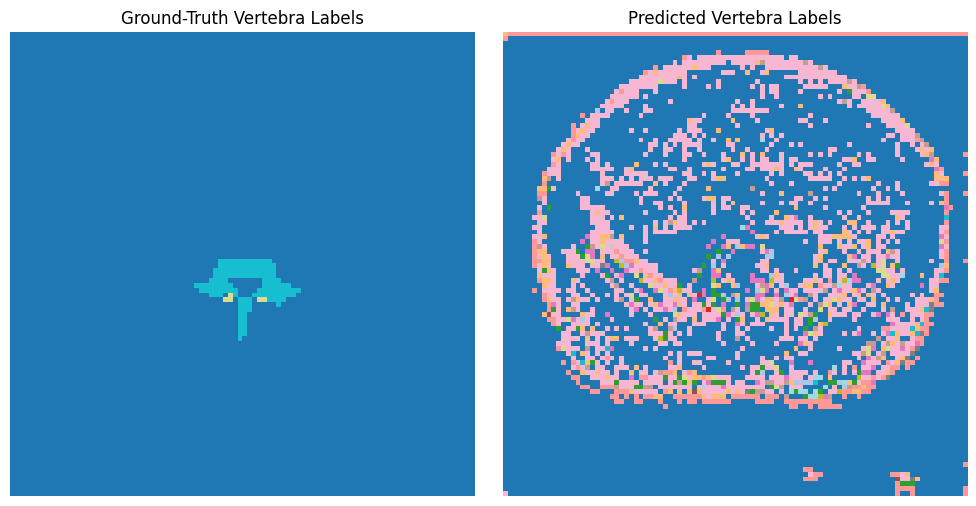

In [53]:
import matplotlib.pyplot as plt

SAMPLE_INDEX = 0  # change this to inspect a different volume
sample_source = val_ds if len(val_ds) > 0 else train_ds

sample = sample_source[SAMPLE_INDEX]
image_tensor = sample["image"].unsqueeze(0).to(device)          # (1, 1, D, H, W)
true_label = sample["label"][0].numpy().astype(np.int64)         # (D, H, W) ground-truth vertebra indices
true_lesion_targets = sample["lesion_targets"].numpy()
true_present = sample["vertebra_present"].numpy()

inference_seg_model.eval()
inference_classifier.eval()

with torch.no_grad():
    seg_logits = inference_seg_model(image_tensor)
    pred_label = torch.argmax(seg_logits, dim=1)[0]               # (D, H, W) tensor

    ct_vol = image_tensor[0, 0]
    pred_results = {}
    for i, name in enumerate(VERTEBRA_LABELS):
        vertebra_idx = i + 1
        voxel_count = int((pred_label == vertebra_idx).sum().item())
        if voxel_count < MIN_VERTEBRA_VOXELS:
            continue
        crop = crop_vertebra(ct_vol, pred_label, vertebra_idx=vertebra_idx)
        if crop is None:
            continue
        logits = inference_classifier(crop.to(device))
        probs = torch.softmax(logits, dim=1)[0]
        pred_class_idx = int(torch.argmax(probs).item())
        pred_results[name] = (LESION_CLASSES[pred_class_idx], float(probs[pred_class_idx].item()))

pred_label_np = pred_label.cpu().numpy()

# ---- per-vertebra comparison table: actual vs predicted lesion class ----
print(f"Sample index: {SAMPLE_INDEX}  (patient: {sample_source.data[SAMPLE_INDEX].get('patient_id', '?')})")
print(f"{'Vertebra':<10}{'Actual':<12}{'Predicted':<20}")
shown = [name for i, name in enumerate(VERTEBRA_LABELS) if true_present[i] > 0 or name in pred_results]
for name in shown:
    i = VERTEBRA_LABELS.index(name)
    actual = LESION_CLASSES[true_lesion_targets[i]] if true_present[i] > 0 else "-"
    if name in pred_results:
        pred_cls, conf = pred_results[name]
        predicted = f"{pred_cls} ({conf:.2f})"
    else:
        predicted = "-"
    print(f"{name:<10}{actual:<12}{predicted:<20}")

# ---- visual comparison: middle slice, ground-truth vs predicted vertebra segmentation ----
mid = true_label.shape[0] // 2
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(true_label[mid], cmap="tab20", vmin=0, vmax=NUM_SEG_CLASSES - 1)
axes[0].set_title("Ground-Truth Vertebra Labels")
axes[0].axis("off")
axes[1].imshow(pred_label_np[mid], cmap="tab20", vmin=0, vmax=NUM_SEG_CLASSES - 1)
axes[1].set_title("Predicted Vertebra Labels")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [54]:
import os
import shutil
from google.colab import files

EXPORT_SEG_NAME = "spine_vertebra_segmentation_model.pth"
EXPORT_CLS_NAME = "spine_lesion_classifier_model.pth"

if os.path.exists(SEG_CHECKPOINT_PATH):
    shutil.copy(SEG_CHECKPOINT_PATH, EXPORT_SEG_NAME)
    print(f"Downloading {EXPORT_SEG_NAME} ...")
    files.download(EXPORT_SEG_NAME)
else:
    print(f"Not found: {SEG_CHECKPOINT_PATH} — train the model first (cell 14).")

if os.path.exists(CLS_CHECKPOINT_PATH):
    shutil.copy(CLS_CHECKPOINT_PATH, EXPORT_CLS_NAME)
    print(f"Downloading {EXPORT_CLS_NAME} ...")
    files.download(EXPORT_CLS_NAME)
else:
    print(f"Not found: {CLS_CHECKPOINT_PATH} — train the model first (cell 14).")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>